# Policy-Triggered Decay: Comparison (7k steps)

This notebook compares the final 7k-step policy runs kept for the report.

- Fixed baseline: WSD decay from step 6300 to 7000.
- Policy runs: stable LR after warmup until a policy fires; gate trigger is at 4900.
- Metric thresholds use the 3rd percentile reference values from the 10k WSD run.

In [21]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

In [22]:
LOG_ROOT = Path("../logs")
MAX_STEPS = 7000
DECAY_LENGTH = 700
FINAL_LR_RATIO = 0.25
VAL_LOSS_GATE = 3.585
EARLIEST_TRIGGER = 4900

RUNS = {
    "baseline_7k":   "policy_decay_baseline_7k_20260607-171959",
    "loss_variance": "policy_decay_loss_variance_7k_20260607-172022",
    "grad_snr":      "policy_decay_grad_snr_7k_20260607-172016",
    "combined":      "policy_decay_combined_7k_20260607-172011",
}
FIXED_TRIGGERS = {
    "baseline_7k": {
        "trigger_step": 6300,
        "decay_end_step": 7000,
        "decay_length": DECAY_LENGTH,
        "final_lr_ratio": FINAL_LR_RATIO,
    },
}
POLICY_THRESHOLDS = {
    "loss_variance": {"loss_variance_threshold": 0.132},
    "grad_snr": {"grad_snr_threshold": 0.931},
    "combined": {"loss_variance_threshold": 0.132, "grad_snr_threshold": 0.931},
}
COLORS = {
    "baseline_7k":   "black",
    "loss_variance": "steelblue",
    "grad_snr":      "darkorange",
    "combined":      "mediumpurple",
}
DISPLAY_NAMES = {
    "baseline_7k":   "Baseline (fixed 6.3k)",
    "loss_variance": "Loss variance",
    "grad_snr":      "Grad SNR",
    "combined":      "Combined",
}

def read_jsonl(path):
    with open(path) as f:
        return pd.DataFrame(json.loads(line) for line in f if line.strip())

data = {}
for key, folder in RUNS.items():
    log_dir = LOG_ROOT / folder
    assert log_dir.exists(), f"Run folder not found: {log_dir}"
    metrics = read_jsonl(log_dir / "metrics.jsonl")
    trigger = None
    if (log_dir / "policy_trigger.json").exists():
        with open(log_dir / "policy_trigger.json") as f:
            trigger = json.load(f)
    elif key in FIXED_TRIGGERS:
        trigger = FIXED_TRIGGERS[key]
    data[key] = {
        "log_dir": log_dir,
        "metrics": metrics,
        "train": metrics[metrics["train_loss"].notna()].reset_index(drop=True),
        "val":   metrics[metrics["validation_loss"].notna()].reset_index(drop=True),
        "trigger": trigger,
    }

for key, d in data.items():
    t = d["trigger"]
    trig_str = f"step {t['trigger_step']}" if t else "none"
    final_val = d["val"]["validation_loss"].iloc[-1]
    print(f"{key:15s}  trigger={trig_str:14s}  val_rows={len(d['val']):3d}  final_val={final_val:.4f}")

baseline_7k      trigger=step 6300       val_rows=140  final_val=3.4952
loss_variance    trigger=step 6101       val_rows=140  final_val=3.4905
grad_snr         trigger=step 6107       val_rows=140  final_val=3.4928
combined         trigger=step 6150       val_rows=140  final_val=3.4939


## Validation Loss Curves and Trigger Points

Dashed vertical lines mark the fixed or policy-triggered decay start.


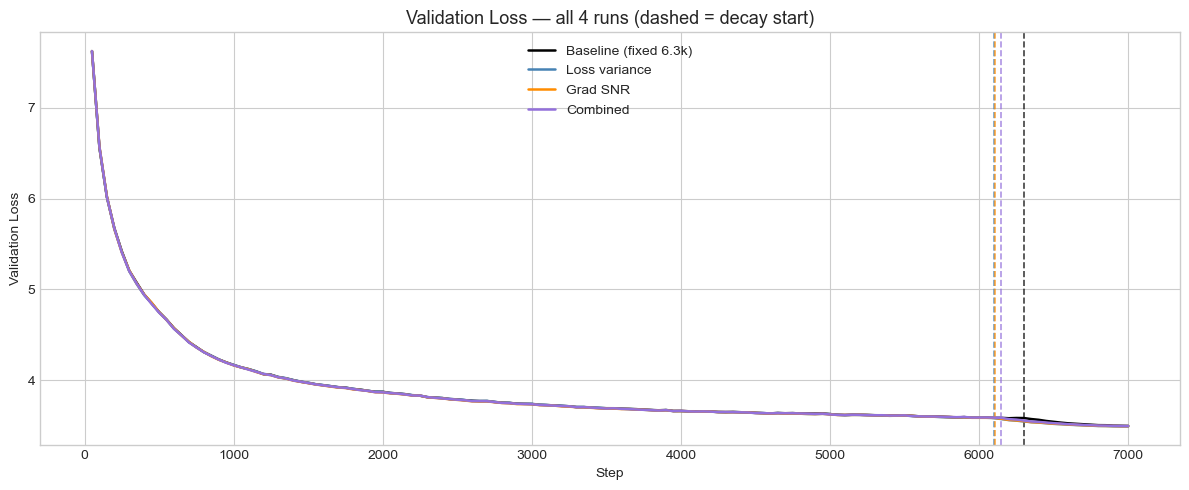

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))

for key, d in data.items():
    val = d["val"]
    trig_step = d["trigger"]["trigger_step"] if d["trigger"] else None
    ax.plot(val["step"], val["validation_loss"],
            color=COLORS[key], linewidth=1.8, label=DISPLAY_NAMES[key])
    if trig_step:
        ax.axvline(trig_step, color=COLORS[key], linewidth=1.2, linestyle="--", alpha=0.75)

ax.set_xlabel("Step")
ax.set_ylabel("Validation Loss")
ax.set_title("Validation Loss — all 4 runs (dashed = decay start)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## Learning Rate Schedules

This verifies when each run actually entered decay and whether the policy runs received more or fewer reduced-LR steps than the fixed baseline.


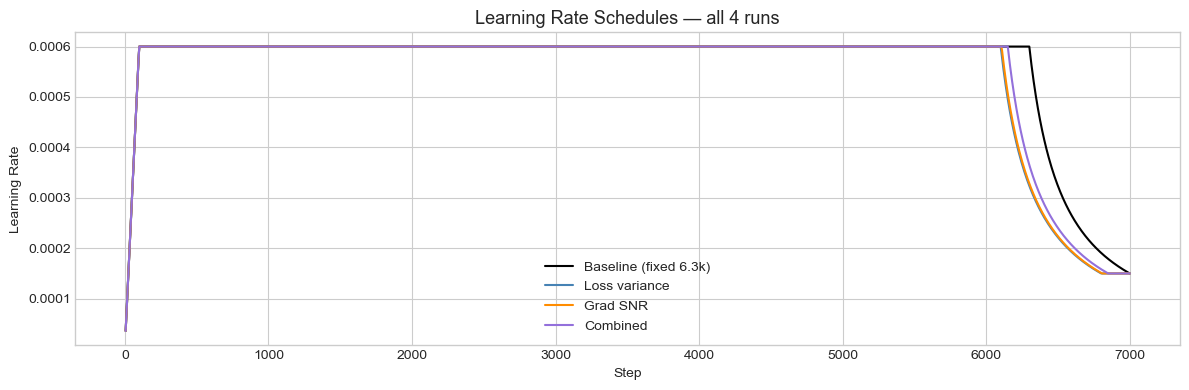

In [25]:
fig, ax = plt.subplots(figsize=(12, 4))

for key, d in data.items():
    train = d["train"]
    ax.plot(train["step"], train["learning_rate"],
            color=COLORS[key], linewidth=1.5, label=DISPLAY_NAMES[key])

ax.set_xlabel("Step")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedules — all 4 runs", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## Why Did Each Policy Trigger?

The panels show the metric trajectory, threshold, gate crossing, and actual trigger step.


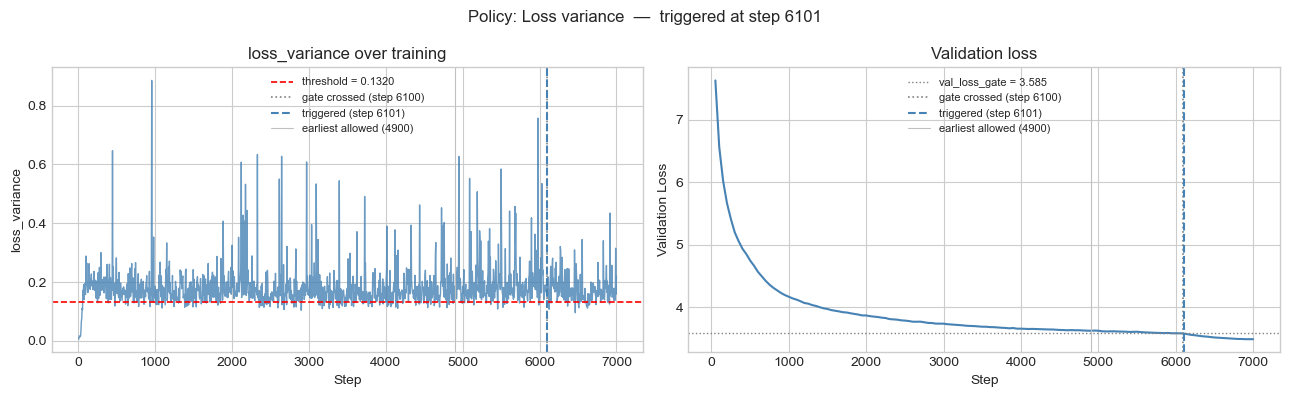

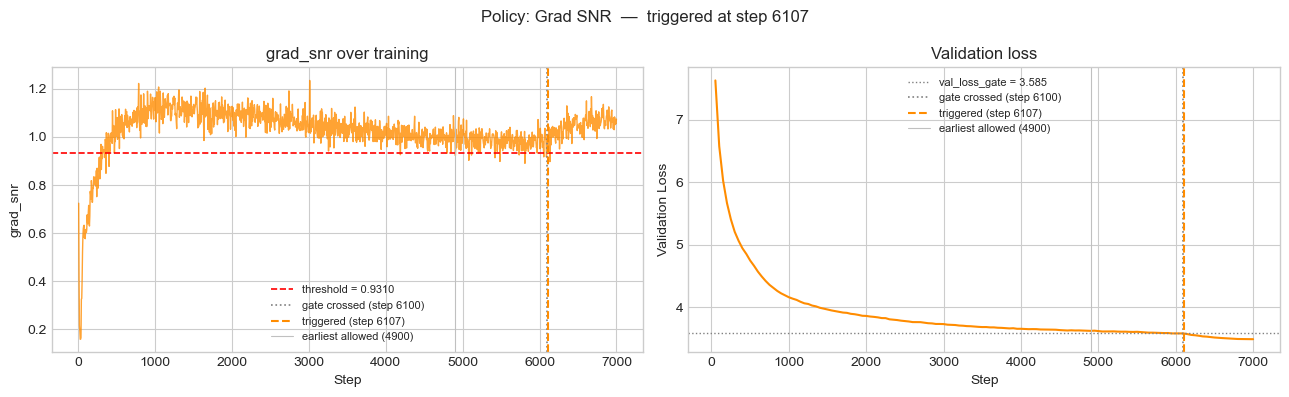

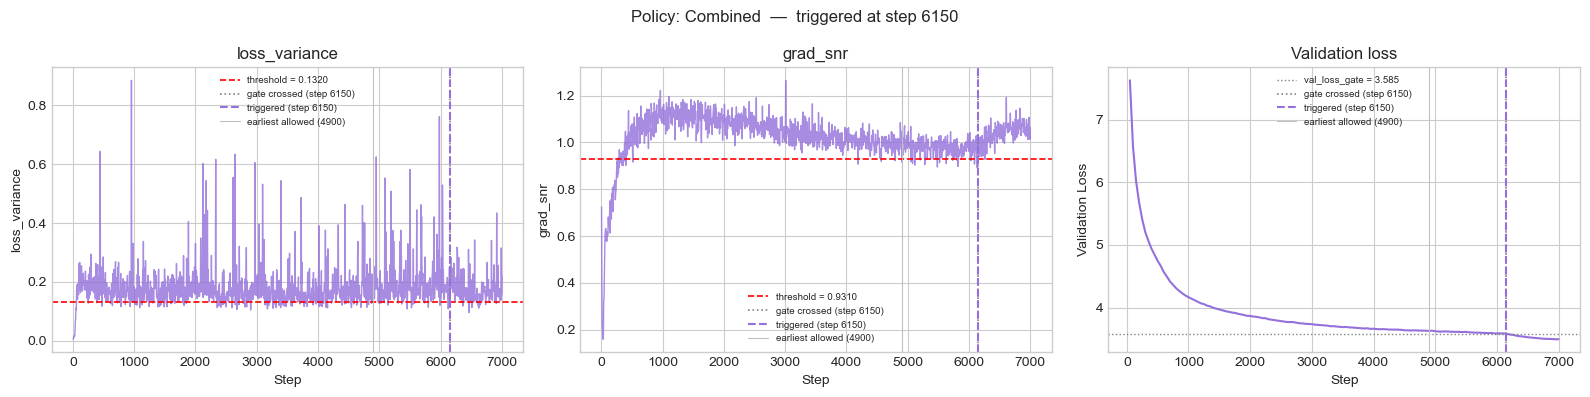

In [26]:
def _gate_step(val_df, gate=VAL_LOSS_GATE):
    below = val_df[val_df["validation_loss"] < gate]
    return int(below["step"].iloc[0]) if len(below) > 0 else None

def _draw_trigger_lines(ax, gate_s, trig_s, color):
    if gate_s is not None:
        ax.axvline(gate_s, color="gray", linewidth=1.2, linestyle=":",
                   label=f"gate crossed (step {gate_s})")
    if trig_s is not None:
        ax.axvline(trig_s, color=color, linewidth=1.5, linestyle="--",
                   label=f"triggered (step {trig_s})")
    ax.axvline(EARLIEST_TRIGGER, color="silver", linewidth=0.8, linestyle="-",
               label=f"earliest allowed ({EARLIEST_TRIGGER})")

# ----- loss_variance and grad_snr -----
for key, metric_col in [("loss_variance", "loss_variance"), ("grad_snr", "grad_snr")]:
    d = data[key]
    trigger = d["trigger"]
    trig_s = trigger["trigger_step"] if trigger else None
    threshold = trigger.get("computed_thresholds", {}).get(f"{metric_col}_threshold") or POLICY_THRESHOLDS.get(key, {}).get(f"{metric_col}_threshold")
    gate_s = _gate_step(d["val"])
    color = COLORS[key]

    fig, (ax_m, ax_v) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"Policy: {DISPLAY_NAMES[key]}  —  triggered at step {trig_s}", fontsize=12)

    train = d["train"]
    ax_m.plot(train["step"], train[metric_col], color=color, linewidth=1, alpha=0.8)
    if threshold is not None:
        ax_m.axhline(threshold, color="red", linewidth=1.2, linestyle="--",
                     label=f"threshold = {threshold:.4f}")
    _draw_trigger_lines(ax_m, gate_s, trig_s, color)
    ax_m.set_xlabel("Step"); ax_m.set_ylabel(metric_col)
    ax_m.set_title(f"{metric_col} over training")
    ax_m.legend(fontsize=8)

    val = d["val"]
    ax_v.plot(val["step"], val["validation_loss"], color=color, linewidth=1.5)
    ax_v.axhline(VAL_LOSS_GATE, color="gray", linewidth=1, linestyle=":",
                 label=f"val_loss_gate = {VAL_LOSS_GATE}")
    _draw_trigger_lines(ax_v, gate_s, trig_s, color)
    ax_v.set_xlabel("Step"); ax_v.set_ylabel("Validation Loss")
    ax_v.set_title("Validation loss")
    ax_v.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

# ----- combined (3 panels) -----
key = "combined"
d = data[key]
trigger = d["trigger"]
trig_s = trigger["trigger_step"] if trigger else None
gate_s = _gate_step(d["val"])
color = COLORS[key]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f"Policy: Combined  —  triggered at step {trig_s}", fontsize=12)

train = d["train"]
for ax, metric_col in [(ax1, "loss_variance"), (ax2, "grad_snr")]:
    threshold = trigger.get("computed_thresholds", {}).get(f"{metric_col}_threshold") or POLICY_THRESHOLDS.get(key, {}).get(f"{metric_col}_threshold")
    ax.plot(train["step"], train[metric_col], color=color, linewidth=1, alpha=0.8)
    if threshold is not None:
        ax.axhline(threshold, color="red", linewidth=1.2, linestyle="--",
                   label=f"threshold = {threshold:.4f}")
    _draw_trigger_lines(ax, gate_s, trig_s, color)
    ax.set_xlabel("Step"); ax.set_ylabel(metric_col)
    ax.set_title(metric_col)
    ax.legend(fontsize=7)

ax3.plot(d["val"]["step"], d["val"]["validation_loss"], color=color, linewidth=1.5)
ax3.axhline(VAL_LOSS_GATE, color="gray", linewidth=1, linestyle=":",
            label=f"val_loss_gate = {VAL_LOSS_GATE}")
_draw_trigger_lines(ax3, gate_s, trig_s, color)
ax3.set_xlabel("Step"); ax3.set_ylabel("Validation Loss")
ax3.set_title("Validation loss")
ax3.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Decay Window Zoom (steps 5500-7000)

This is the main curve-level comparison for the policy experiment.


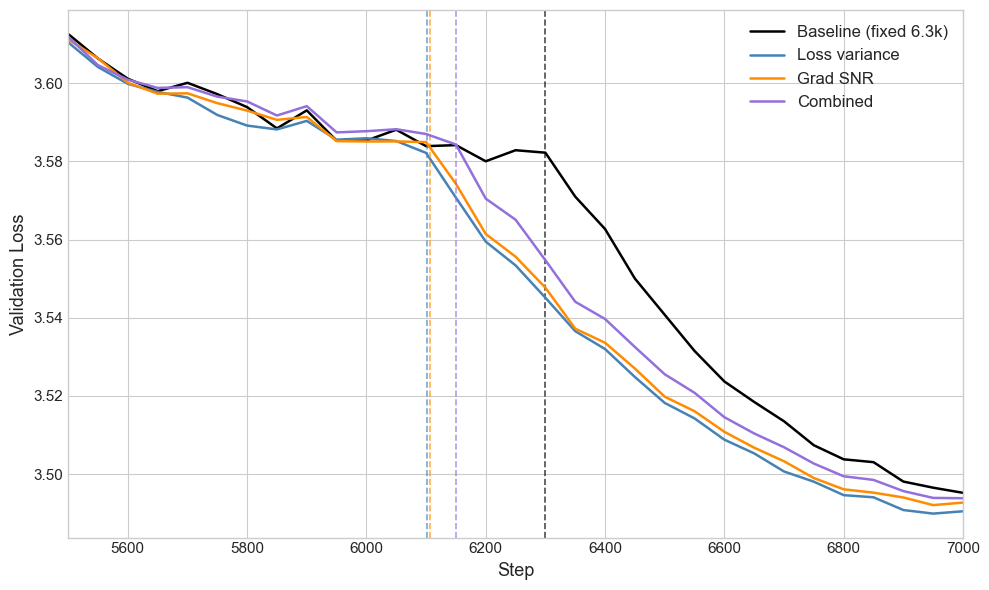

In [28]:
ZOOM_START = 5500

fig, ax = plt.subplots(figsize=(10, 6))

for key, d in data.items():
    val = d["val"]
    mask = val["step"] >= ZOOM_START
    trig_step = d["trigger"]["trigger_step"] if d["trigger"] else None
    ax.plot(val.loc[mask, "step"], val.loc[mask, "validation_loss"],
            color=COLORS[key], linewidth=1.8, label=DISPLAY_NAMES[key])
    if trig_step:
        ax.axvline(trig_step, color=COLORS[key], linewidth=1.2, linestyle="--", alpha=0.7)
ax.set_xlim(ZOOM_START, MAX_STEPS)
ax.set_xlabel("Step", fontsize=13)
ax.set_ylabel("Validation Loss", fontsize=13)
ax.tick_params(labelsize=11)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()
